## 1. Configuración

In [ ]:
MODELO = 'https://drive.google.com/file/d/16hxchfiXWCWUFA8_l6mK4GnK_DCnv5Rm/view?usp=sharing'
FOTOS  = 'https://drive.google.com/file/d/1n4gSJTpws7AnECs0x2f7X_tiSNy_Dr5G/view?usp=sharing'

!pip install -q ultralytics gdown
import cv2, numpy as np, math, json, shutil, zipfile, gdown
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

def traer(fuente, nombre):
    """Link de Drive -> se descarga. Zip -> se descomprime. Devuelve la ruta local."""
    if fuente.startswith('http'):
        fuente = gdown.download(fuente, nombre, fuzzy=True, quiet=True)
    if fuente.endswith('.zip'):
        shutil.rmtree('fotos', ignore_errors=True)
        zipfile.ZipFile(fuente).extractall('fotos')
        fuente = 'fotos'
    return Path(fuente)

modelo = YOLO(traer(MODELO, 'best.pt'))
FOTOS = sorted(p for p in traer(FOTOS, 'fotos.zip').rglob('*')
               if p.suffix.lower() in ('.jpg', '.jpeg', '.png') and '__MACOSX' not in p.parts)
print(len(FOTOS), 'fotos | clases del modelo:', list(modelo.names.values()))

def ver(imgs, titulos, ancho=5):
    fig, ejes = plt.subplots(1, len(imgs), figsize=(ancho * len(imgs), ancho))
    for ax, im, t in zip(np.atleast_1d(ejes), imgs, titulos):
        ax.imshow(im if im.ndim == 2 else im[..., ::-1], cmap='gray'); ax.set_title(t); ax.axis('off')
    plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 3.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
68 fotos | clases del modelo: ['1', '2', '3', '4', '5', '6', 'vacio']


## 2. Visión: preprocesamiento, grilla y recortes

In [ ]:
S, M = 800, 30   # tamaño del tablero rectificado y margen

def preprocesar(img, C=10):
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    bloque = max(15, (min(gris.shape) // 40) | 1)
    binaria = cv2.adaptiveThreshold(cv2.GaussianBlur(gris, (5, 5), 0), 255,
                                    cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, bloque, C)
    k = max(3, min(gris.shape) // 300)        # cierra cortes pequeños en los bordes de las celdas
    return gris, cv2.morphologyEx(binaria, cv2.MORPH_CLOSE, np.ones((k, k), np.uint8))

def detectar_celdas(binaria):
    """Contornos cuadrados y solidos; se queda con los de tamaño mas repetido."""
    t, cand = min(binaria.shape), []
    for c in cv2.findContours(binaria, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)[0]:
        area = cv2.contourArea(c)
        (cx, cy), (w, h), _ = cv2.minAreaRect(c)
        if (t * .03) ** 2 < area < (t * .5) ** 2 and 0.75 < w / h < 1.33 \
                and area / cv2.contourArea(cv2.convexHull(c)) > 0.85 and area / (w * h) > 0.75:
            cand.append((math.sqrt(area), cx, cy, c))
    celdas = []
    for d in sorted(cand, key=lambda d: -d[0]):          # cada celda da 2 contornos: se queda el mayor
        if all(math.hypot(d[1] - e[1], d[2] - e[2]) > .35 * e[0] for e in celdas):
            celdas.append(d)
    if not celdas:
        return []
    lados = np.array([d[0] for d in celdas])
    s = lados[np.argmax([np.sum(abs(lados - l) < .25 * l) for l in lados])]
    return [d for d in celdas if abs(d[0] - s) < .3 * s]

def rectificar(img, celdas):
    """Homografia usando la esquina exterior de las 4 celdas extremas."""
    c = np.array([[d[1], d[2]] for d in celdas])
    esquina = lambda i, sx, sy: max(celdas[i][3].reshape(-1, 2), key=lambda p: sx * p[0] + sy * p[1])
    src = np.float32([esquina(np.argmin(c.sum(1)), -1, -1), esquina(np.argmax(c[:, 0] - c[:, 1]), 1, -1),
                      esquina(np.argmax(c.sum(1)), 1, 1), esquina(np.argmin(c[:, 0] - c[:, 1]), -1, 1)])
    H = cv2.getPerspectiveTransform(src, np.float32([[M, M], [S - M, M], [S - M, S - M], [M, S - M]]))
    return cv2.warpPerspective(img, H, (S, S), borderValue=(255, 255, 255)), src

def analizar(img):
    """Preprocesa, corrige la perspectiva y segmenta la grilla."""
    cuadrado = lambda n: n >= 9 and round(math.sqrt(n)) ** 2 == n
    for C in (10, 5, 2):                      # si la foto esta borrosa, se binariza de forma mas tolerante
        gris, binaria = preprocesar(img, C)
        celdas = detectar_celdas(binaria)
        if cuadrado(len(celdas)):
            break
    if len(celdas) < 9:
        raise ValueError(f'solo {len(celdas)} celdas')
    rect, esquinas = rectificar(img, celdas)
    bin_rect = preprocesar(rect, C)[1]
    celdas_r = detectar_celdas(bin_rect)
    if cuadrado(len(celdas_r)) and len(celdas_r) > len(celdas):   # ya enderezado se ven celdas que faltaban
        celdas = celdas_r
        rect = rectificar(rect, celdas_r)[0]
        bin_rect = preprocesar(rect, C)[1]
        celdas_r = detectar_celdas(bin_rect)
    N = round(math.sqrt(len(celdas)))
    lado = float(np.median([d[0] for d in celdas_r])) if celdas_r else (S - 2 * M) / (1.4 * N)
    paso = (S - 2 * M - lado) / (N - 1)
    centro = lambda r, c: (M + lado / 2 + c * paso, M + lado / 2 + r * paso)
    return dict(gris=gris, binaria=binaria, celdas=celdas, esquinas=esquinas, rect=rect, bin_rect=bin_rect,
                N=N, lado=lado, hueco=paso - lado, centro=centro)

def recortar(a, tam=96):
    """Un recorte por celda y por hueco, con su posicion (fila, columna)."""
    N, lado, hueco, centro = a['N'], a['lado'], a['hueco'], a['centro']
    pos = [('celda', r, c, *centro(r, c)) for r in range(N) for c in range(N)]
    pos += [('h', r, c, (centro(r, c)[0] + centro(r, c + 1)[0]) / 2, centro(r, c)[1]) for r in range(N) for c in range(N - 1)]
    pos += [('v', r, c, centro(r, c)[0], (centro(r, c)[1] + centro(r + 1, c)[1]) / 2) for r in range(N - 1) for c in range(N)]
    out = []
    for tipo, r, c, x, y in pos:
        s = lado * .8 if tipo == 'celda' else hueco * .95
        caja = a['rect'][int(y - s / 2):int(y + s / 2), int(x - s / 2):int(x + s / 2)]
        out.append(dict(tipo=tipo, pos=(r, c), img=cv2.resize(caja, (tam, tam), interpolation=cv2.INTER_AREA)))
    return out

def tiene_contenido(img):
    """Hay tinta impresa si existe una mancha bastante mas oscura que el papel cerca del centro.
    Ignora la textura del papel (poco contraste) y los bordes de celdas vecinas (tocan el borde)."""
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    oscuro = (gris < np.median(gris) - 40).astype(np.uint8)
    n, _, stats, centros = cv2.connectedComponentsWithStats(oscuro)
    t = img.shape[0]
    for (x, y, w, h, area), (cx, cy) in zip(stats[1:], centros[1:]):
        if area >= 40 and .2 * t < cx < .8 * t and .2 * t < cy < .8 * t:
            return True
    return False

## 3. Foto → JSON

- Recortes sin contenido → se ignoran.
- Celdas → YOLO dice el dígito (solo se aceptan dígitos entre 1 y N).
- Huecos → OpenCV lee el signo. Los verticales se guardan como `<` / `>` entre la celda de arriba y la de abajo (`^` → arriba menor → `<`).

Formato: `X[row1][col1] <type> X[row2][col2]`.

In [ ]:
def leer_signo(img, tipo):
    """Regla geometrica: el signo es angosto en su vertice y ancho en su lado abierto.
    La punta siempre apunta a la celda menor."""
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)[10:-10, 10:-10]
    b = cv2.threshold(gris, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
    n, comp, stats, _ = cv2.connectedComponentsWithStats(b)
    ys, xs = np.nonzero(comp == 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA]))   # trazo principal
    a, c = (xs, ys) if tipo == 'h' else (ys, xs)          # a: eje a lo largo del hueco, c: eje transversal
    t = (a.max() - a.min()) * .3
    punta_al_inicio = np.ptp(c[a <= a.min() + t]) < np.ptp(c[a >= a.max() - t])
    if tipo == 'h':
        return 'less_than' if punta_al_inicio else 'greater_than'     # punta a la izquierda: <
    return 'up_than' if punta_al_inicio else 'down_than'              # punta arriba: ^


def foto_a_json(ruta):
    """Foto -> estado inicial del Futoshiki."""
    a = analizar(cv2.imread(str(ruta)))
    N = a['N']
    estado = {'grid_size': N, 'initial_digits': [], 'inequalities': []}
    recortes = [rc for rc in recortar(a) if tiene_contenido(rc['img'])]
    celdas = [rc for rc in recortes if rc['tipo'] == 'celda']
    if celdas:                                                  # digitos -> YOLO
        for rc, res in zip(celdas, modelo.predict([rc['img'] for rc in celdas], imgsz=96, verbose=False)):
            # la clase mas probable que tenga sentido: 'vacio' o un digito entre 1 y N
            validas = [i for i in res.probs.data.argsort(descending=True).tolist()
                       if res.names[i] == 'vacio' or int(res.names[i]) <= N]
            clase = res.names[validas[0]]
            if clase != 'vacio':
                r, c = rc['pos']
                estado['initial_digits'].append({'row': r, 'col': c, 'value': int(clase)})
    for rc in recortes:                                         # signos -> OpenCV
        if rc['tipo'] == 'celda':
            continue
        r, c = rc['pos']
        r2, c2 = (r, c + 1) if rc['tipo'] == 'h' else (r + 1, c)
        signo = leer_signo(rc['img'], rc['tipo'])
        # la punta apunta al menor: '<' y '^' => primera celda menor
        tipo = '<' if signo in ('less_than', 'up_than') else '>'
        estado['inequalities'].append({'row1': r, 'col1': c, 'row2': r2, 'col2': c2, 'type': tipo})
    return estado, a


def dibujar_estado(estado, tam=420):
    """Redibuja el tablero a partir del JSON, para compararlo con la foto."""
    N = estado['grid_size']
    img = np.full((tam, tam, 3), 255, np.uint8)
    lado = (tam - 40) / (N + (N - 1) * .4); sep = lado * .4
    pos = lambda i: 20 + i * (lado + sep)
    texto = lambda s, x, y, f: cv2.putText(img, s, (int(x - 9 * f), int(y + 9 * f)), cv2.FONT_HERSHEY_SIMPLEX, f, (0, 0, 0), 2)
    for r in range(N):
        for c in range(N):
            cv2.rectangle(img, (int(pos(c)), int(pos(r))), (int(pos(c) + lado), int(pos(r) + lado)), (0, 0, 0), 2)
    for d in estado['initial_digits']:
        texto(str(d['value']), pos(d['col']) + lado / 2, pos(d['row']) + lado / 2, lado / 40)
    for q in estado['inequalities']:
        if q['row1'] == q['row2']:
            texto(q['type'], pos(q['col1']) + lado + sep / 2, pos(q['row1']) + lado / 2, sep / 30)
        else:
            texto('^' if q['type'] == '<' else 'v', pos(q['col1']) + lado / 2, pos(q['row1']) + lado + sep / 2, sep / 30)
    return img


def revisar(estado):
    """Avisa si la lectura no puede ser un Futoshiki valido (asi un error no llega al solver)."""
    avisos, grilla = [], {(d['row'], d['col']): d['value'] for d in estado['initial_digits']}
    for i in range(estado['grid_size']):
        for nombre, valores in (('fila', [v for (r, c), v in grilla.items() if r == i]),
                                ('columna', [v for (r, c), v in grilla.items() if c == i])):
            repetidos = {v for v in valores if valores.count(v) > 1}
            if repetidos:
                avisos.append(f'{nombre} {i} repite {sorted(repetidos)}')
    for q in estado['inequalities']:
        a, b = grilla.get((q['row1'], q['col1'])), grilla.get((q['row2'], q['col2']))
        if a and b and not (a < b if q['type'] == '<' else a > b):
            avisos.append(f"{a} {q['type']} {b} es falso en ({q['row1']},{q['col1']})-({q['row2']},{q['col2']})")
    return avisos

## 4. Procesar las fotos
A la izquierda la foto; a la derecha el tablero redibujado desde el JSON. Si coinciden, la lectura es correcta.
Si aparece **REVISAR**, la lectura tiene un error evidente (un dígito repetido o un signo que contradice dos dígitos).

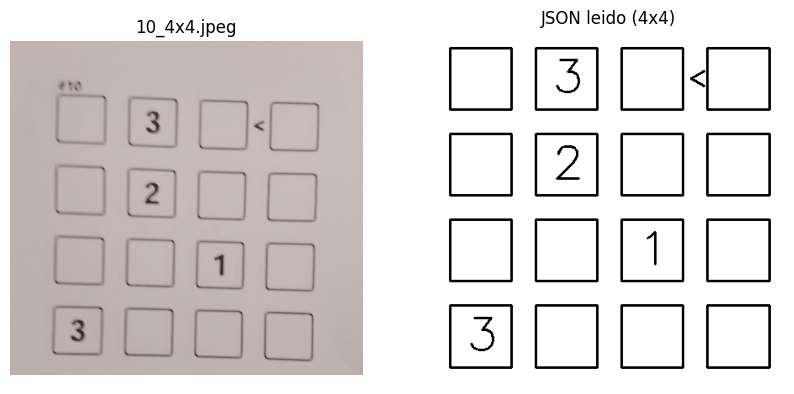

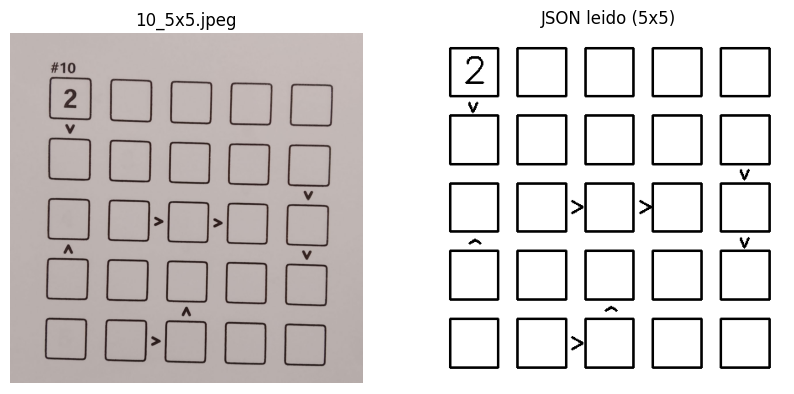

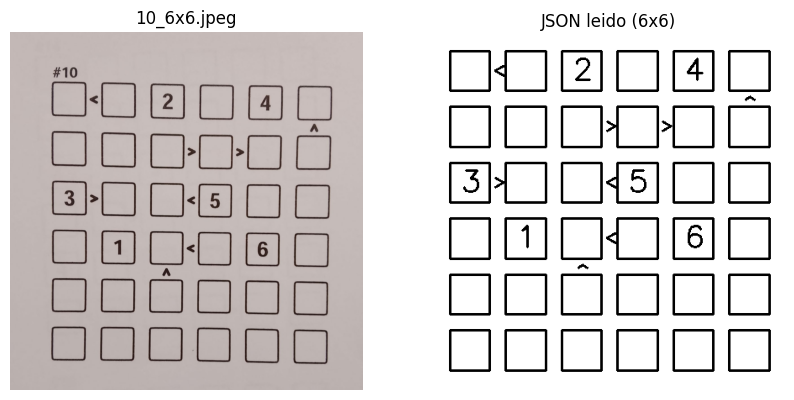

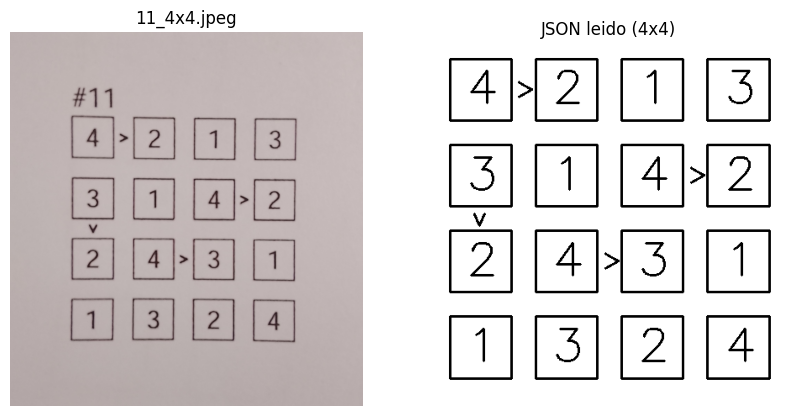

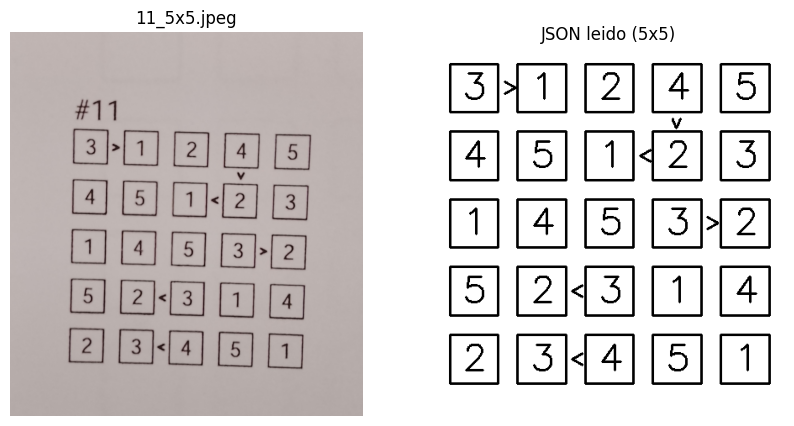

...

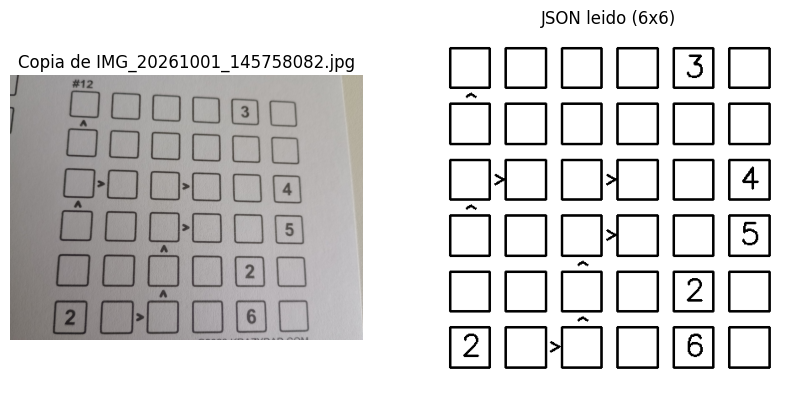

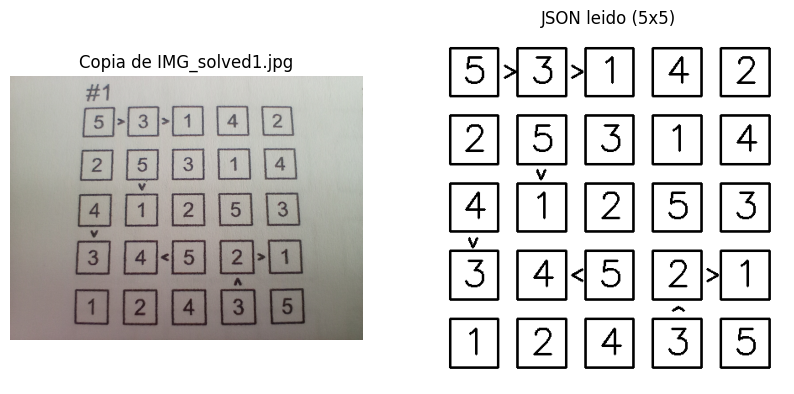

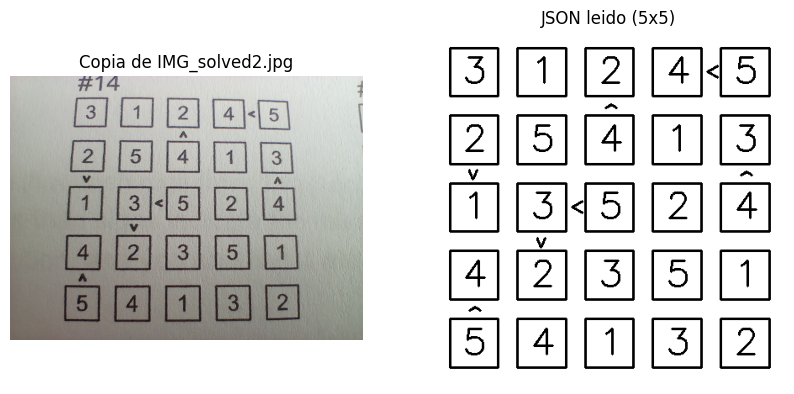

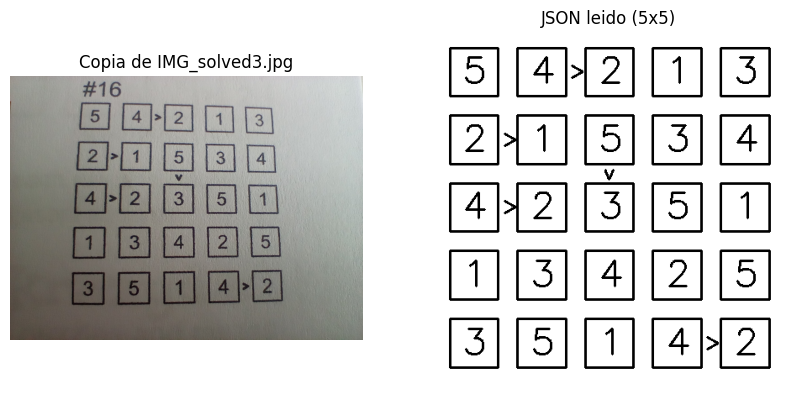

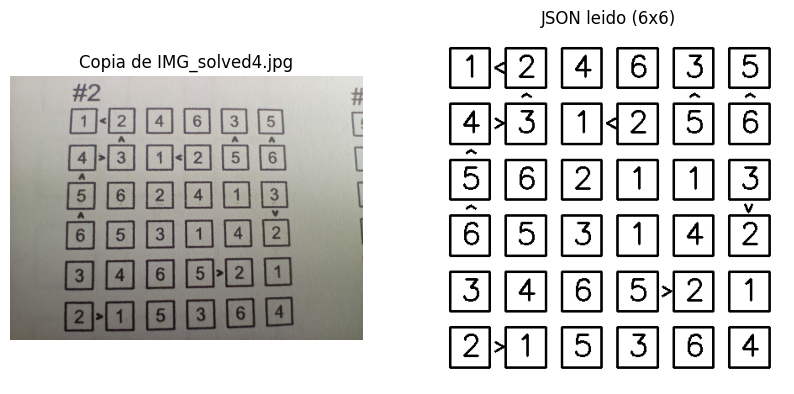

  REVISAR: fila 2 repite [1]
  REVISAR: columna 3 repite [1]


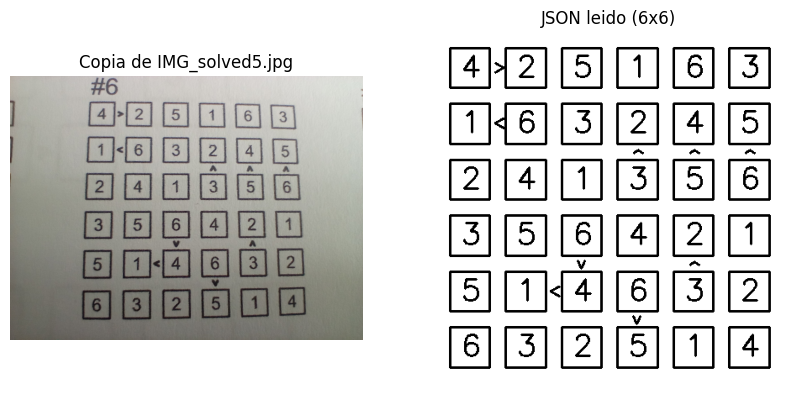

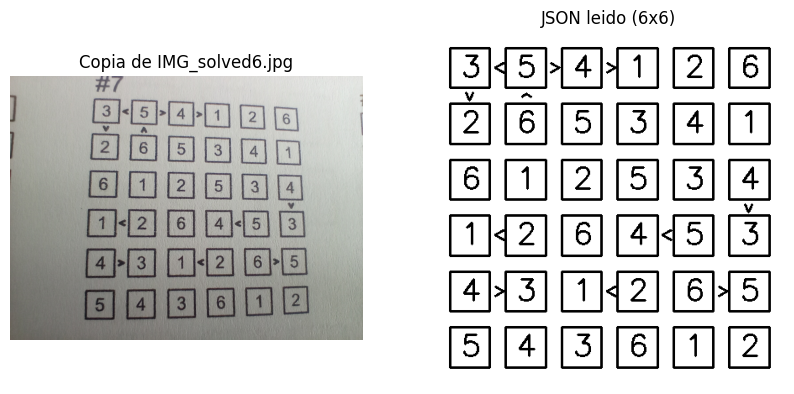

In [ ]:


 Path('json').mkdir(exist_ok=True)
aciertos = {'tableros': 0, 'digitos': [0, 0], 'signos': [0, 0]}
con_respuesta = 0
for ruta in FOTOS:
    try:
        estado, a = foto_a_json(ruta)
    except Exception as e:
        print(f'{ruta.name}: no se encontro la grilla ({e})'); continue
    Path('json', ruta.stem + '.json').write_text(json.dumps(estado, indent=2))
    ver([cv2.imread(str(ruta)), dibujar_estado(estado)], [ruta.name, f"JSON leido ({estado['grid_size']}x{estado['grid_size']})"])
    for aviso in revisar(estado):
        print('  REVISAR:', aviso)

    gt = ruta.with_suffix('.json')                              # respuesta correcta, si existe
    if gt.exists():
        gt = json.loads(gt.read_text()); con_respuesta += 1
        dig = lambda e: {(d['row'], d['col'], d['value']) for d in e['initial_digits']}
        sig = lambda e: {(q['row1'], q['col1'], q['row2'], q['col2'], q['type']) for q in e['inequalities']}
        aciertos['digitos'][0] += len(dig(estado) & dig(gt)); aciertos['digitos'][1] += len(dig(gt) | dig(estado))
        aciertos['signos'][0] += len(sig(estado) & sig(gt)); aciertos['signos'][1] += len(sig(gt) | sig(estado))
        exacto = estado['grid_size'] == gt['grid_size'] and dig(estado) == dig(gt) and sig(estado) == sig(gt)
        aciertos['tableros'] += exacto
        print('correcto' if exacto else f"ERRORES -> digitos de mas: {dig(estado) - dig(gt)}, faltan: {dig(gt) - dig(estado)}"
              f" | signos de mas: {sig(estado) - sig(gt)}, faltan: {sig(gt) - sig(estado)}")

if con_respuesta:
    d, s = aciertos['digitos'], aciertos['signos']
    print(f"\nTableros leidos sin errores: {aciertos['tableros']}/{con_respuesta}")
    print(f"Digitos correctos: {d[0]}/{d[1]} ({d[0] / max(d[1], 1):.1%})   Signos correctos: {s[0]}/{s[1]} ({s[0] / max(s[1], 1):.1%})")

## 5. Descargar los JSON

In [ ]:
shutil.make_archive('json', 'zip', 'json')
try:                                                   # Colab: descarga los JSON
    from google.colab import files
    files.download('json.zip')
except ImportError:                                    # local: ya estan en la carpeta json
    print('JSON guardados en', Path('json').resolve())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>